In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
import warnings
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder
)

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from feature_engine.datetime import DatetimeFeatures

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from utils import eda_helper_functions
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import IsolationForest
import sklearn

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    PowerTransformer,
    FunctionTransformer
)

from feature_engine.outliers import Winsorizer
from feature_engine.datetime import DatetimeFeatures
from feature_engine.selection import SelectBySingleFeaturePerformance
from feature_engine.encoding import (
    RareLabelEncoder,
    MeanEncoder,
    CountFrequencyEncoder
)

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

import warnings
pd.set_option('display.max_columns',None)
sklearn.set_config(transform_output = "pandas")
warnings.filterwarnings("ignore")

In [3]:
dtoj_transformer = Pipeline(steps = [
    ("dt",DatetimeFeatures(features_to_extract = ['weekend'],yearfirst = True,format = "mixed"))
])

In [4]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.feature_utils import (
    is_north, part_of_month, part_of_day,
    make_month_object, have_info,
    duration_category,is_same_region,direct_flight
)
from utils.rbf import RBFPercentileSimilarity,RouteCreator


In [5]:
import joblib

load_path = os.path.join("..", "artifacts", "latest_column_transformer.joblib")

# Load the column transformer
column_transformer = joblib.load(load_path)


print("✅ latest_column_transformer loaded successfully.")


✅ latest_column_transformer loaded successfully.


In [6]:
X_train_transformed = pd.read_csv("../transformed_data/X_train_transformed.csv")
X_test_transformed = pd.read_csv("../transformed_data/X_test_transformed.csv")
X_val_transformed = pd.read_csv("../transformed_data/X_val_transformed.csv")

y_train = pd.read_csv("../data/processed/train_data.csv").price
y_test = pd.read_csv("../data/processed/test_data.csv").price
y_val = pd.read_csv("../data/processed/val_data.csv").price

In [7]:
test_data = pd.read_csv("../data/processed/test_data.csv")
test_data.query("price > 20000")

,airline,source,destination,duration,total_stops,additional_info,dep_time_hour,dep_time_min,dtoj_day,dtoj_month,dtoj_year,route_key,price
112,Air India,mumbai,hyderabad,845,2,no info,9,40,6,3,2019,"('mumbai', 'hyderabad')",22619
162,Jet Airways,banglore,new delhi,1210,1,1 long layover,8,55,1,3,2019,"('banglore', 'new delhi')",26890
218,Jet Airways,banglore,new delhi,1425,1,no info,11,40,1,3,2019,"('banglore', 'new delhi')",25735
219,Multiple Carriers,delhi,cochin,630,2,no info,15,5,9,3,2019,"('delhi', 'cochin')",34608
262,Jet Airways,delhi,cochin,1995,2,no info,19,10,6,3,2019,"('delhi', 'cochin')",20694
296,Multiple Carriers,delhi,cochin,565,3,no info,11,35,6,3,2019,"('delhi', 'cochin')",21829
305,Jet Airways,banglore,new delhi,1045,1,no info,11,40,1,3,2019,"('banglore', 'new delhi')",22270
393,Jet Airways,banglore,new delhi,400,1,business class,5,45,1,3,2019,"('banglore', 'new delhi')",62427
405,Jet Airways,banglore,new delhi,365,1,no info,16,55,1,3,2019,"('banglore', 'new delhi')",54826
422,Jet Airways,banglore,new delhi,800,1,no info,7,0,1,3,2019,"('banglore', 'new delhi')",27992


### Model Tuning

In [8]:
# Taking the XGBoost Model 

import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import joblib  # for saving model

def objective(trial):
    # Suggest hyperparameters
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "random_state": 42,
        "n_jobs": -1
    }

    # Model
    model = XGBRegressor(**param)

    # Fit on training data
    model.fit(X_train_transformed, y_train)

    # Predict on tuning set
    preds = model.predict(X_val_transformed)

    # Evaluation metric
    mse = mean_squared_error(y_val, preds)
    return mse  # Minimize MSE


In [9]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100) 

[I 2026-05-07 20:56:00,490] A new study created in memory with name: no-name-373a7bd1-a290-4059-9b50-437e1fabf056


[I 2026-05-07 20:56:06,067] Trial 0 finished with value: 4310388.0 and parameters: {'n_estimators': 569, 'max_depth': 10, 'learning_rate': 0.1300204609037475, 'subsample': 0.7435268016098249, 'colsample_bytree': 0.834924551522402, 'gamma': 4.433797947035769, 'min_child_weight': 9, 'reg_alpha': 8.064555236349296, 'reg_lambda': 3.980916747076538}. Best is trial 0 with value: 4310388.0.
[I 2026-05-07 20:56:11,018] Trial 1 finished with value: 4534950.0 and parameters: {'n_estimators': 804, 'max_depth': 15, 'learning_rate': 0.12414607888766903, 'subsample': 0.5060233752844723, 'colsample_bytree': 0.9484406261359088, 'gamma': 8.469567189161634, 'min_child_weight': 2, 'reg_alpha': 0.34647494373362675, 'reg_lambda': 9.292274607317308}. Best is trial 0 with value: 4310388.0.
[I 2026-05-07 20:56:15,606] Trial 2 finished with value: 3994366.5 and parameters: {'n_estimators': 841, 'max_depth': 18, 'learning_rate': 0.047959228790426967, 'subsample': 0.7702283845191156, 'colsample_bytree': 0.801703

In [10]:
best_params = study.best_params
best_params["random_state"] = 42
best_params["n_jobs"] = -1

final_model = XGBRegressor(**best_params)
final_model.fit(X_train_transformed, y_train)

model_dir = os.path.join("..", "artifacts", "models")
os.makedirs(model_dir, exist_ok=True)

# Full save path for model
model_path = os.path.join(model_dir, "xgb_flight_price_model.joblib")

# Save the model
joblib.dump(final_model, model_path)

print(f"✅ Final model trained and saved as {model_path}")

✅ Final model trained and saved as ..\artifacts\models\xgb_flight_price_model.joblib


### Loading the model

In [11]:
import joblib
models_path = os.path.join("..", "artifacts", "models")
xgboostmodel_path = os.path.join(models_path,"xgb_flight_price_model.joblib")
final_model = joblib.load(xgboostmodel_path)
print("✅ Model loaded successfully.")

✅ Model loaded successfully.


### Checking performance on Test data 

In [12]:
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error

y_test_pred = final_model.predict(X_test_transformed)

print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Test R²:", r2_score(y_test, y_test_pred))

Test MSE: 4521429.5
Test MAE: 977.5390014648438
Test RMSE: 2126.36532609051
Test R²: 0.8061962127685547


### Checking if the model is overfitting or not

In [13]:
# First on training data

y_train_pred = final_model.predict(X_train_transformed)

print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train R²:", r2_score(y_train, y_train_pred))

Train MSE: 2425603.0
Train MAE: 759.6234130859375
Train RMSE: 1557.4347498370519
Train R²: 0.8853698968887329


In [14]:
# On validation data

y_val_pred = final_model.predict(X_val_transformed)

print("Val MSE:", mean_squared_error(y_val, y_val_pred))
print("Val MAE:", mean_absolute_error(y_val, y_val_pred))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("Val R²:", r2_score(y_val, y_val_pred))

Val MSE: 3361606.75
Val MAE: 956.5418090820312
Val RMSE: 1833.4685025928316
Val R²: 0.8307368755340576


In [15]:
cleaned_flight_data = pd.read_csv("../data/processed/cleaned_flight_data.csv")

In [16]:
cleaned_flight_data["date"] = pd.to_datetime(cleaned_flight_data.rename(columns={'dtoj_year': 'year', 
                                     'dtoj_month': 'month', 
                                     'dtoj_day': 'day'})[['year', 'month', 'day']])
weekend = dtoj_transformer.fit_transform(cleaned_flight_data[['date']])
cleaned_flight_data = cleaned_flight_data.assign(is_weekend = weekend)
cleaned_flight_data.drop(columns = ['dep_time_min','dtoj_year'],inplace = True)

X = cleaned_flight_data.drop(columns = ['price'])
y = cleaned_flight_data.price

In [17]:
cleaned_flight_data.head(2)

,airline,source,destination,duration,total_stops,additional_info,price,dep_time_hour,dtoj_day,dtoj_month,date,is_weekend
0,Indigo,banglore,new delhi,170,0,no info,3897,22,24,3,2019-03-24,1
1,Air India,kolkata,banglore,445,2,no info,7662,5,1,5,2019-05-01,0


In [18]:
import joblib

# Define the path to the column transformer
load_path = os.path.join("..", "artifacts", "latest_column_transformer.joblib")

# Load the column transformer
column_transformer = joblib.load(load_path)


print("✅ latest column_transformer loaded successfully.")


✅ latest column_transformer loaded successfully.


In [19]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline

# Suppose you already have:
# column_transformer (your preprocessing steps)
# best_model (your tuned ML model, e.g. RandomForest with best params)

# Build pipeline = preprocessing + tuned model
final_pipeline = Pipeline(steps=[
    ('preprocess', column_transformer),
    ('model', final_model)
])

# Define KFold
kfold = KFold(n_splits=5, shuffle=True)

# Run CV
scores = cross_val_score(
    final_pipeline, 
    X,  # full cleaned raw data (without manual splitting)
    y, 
    cv=kfold, 
    scoring='r2'
)

print("Cross-validation R² scores:", scores)
print("Mean R²:", scores.mean())
print("Std Dev:", scores.std())


Cross-validation R² scores: [0.84870052 0.84487921 0.83293271 0.81654882 0.78327006]
Mean R²: 0.8252662658691406
Std Dev: 0.02380034196034547


In [20]:
# Suppose y_true and y_pred are arrays
df = pd.DataFrame({"y_true": y_test, "y_pred": y_test_pred})
df["error"] = abs(df["y_true"] - df["y_pred"])
df["perc_error"] = df["error"] / df["y_true"]

# Price bins (quartiles or custom ranges)
bins = [0, 5000, 10000, 20000, 80000]
labels = ["Budget (<5k)", "Mid (5k-10k)", "Upper-mid (10k-20k)", "Premium (20k+)"]
df["price_bin"] = pd.cut(df["y_true"], bins=bins, labels=labels)

# Aggregate error by bin
df.groupby("price_bin")[["error", "perc_error"]].mean()

,error,perc_error
price_bin,,
Budget (<5k),429.643172,0.113902
Mid (5k-10k),864.879333,0.121733
Upper-mid (10k-20k),1076.270582,0.079510
Premium (20k+),9596.258443,0.283678


In [21]:
print("Total rows below 5000 are",y_train.to_frame().query('price < 5000').shape[0])
print("Total rows between 5000 to 10000 are",y_train.to_frame().query('price < 10000 & price > 5000').shape[0])
print("Total rows between 10000 to 20000 are",y_train.to_frame().query('price < 20000 & price > 10000').shape[0])
print("Total rows above 20000 are",y_train.to_frame().query('price > 20000').shape[0])
print("\nTotal rows are" ,y_train.shape[0])

Total rows below 5000 are 1533
Total rows between 5000 to 10000 are 2470
Total rows between 10000 to 20000 are 2592
Total rows above 20000 are 94

Total rows are 6694


In [22]:
from scipy.stats import spearmanr

corr, _ = spearmanr(y_test, y_test_pred)
print("Spearman Rank Correlation:", corr)


Spearman Rank Correlation: 0.9512646096686973


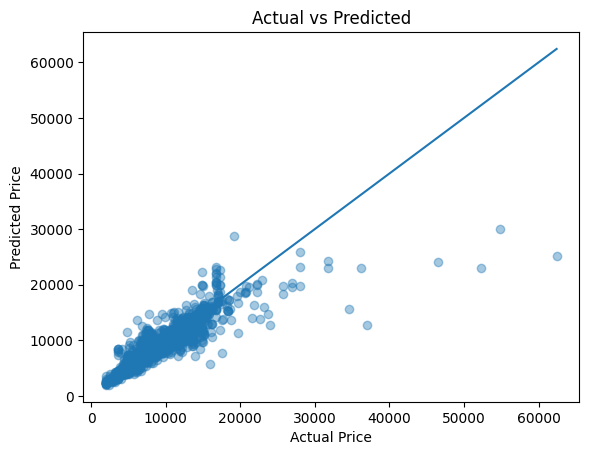

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.4)

# 45-degree line
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


#### Applying the MOE concept

In [24]:
train_df = X_train_transformed.copy()
val_df = X_val_transformed.copy()
train_df['price'] = y_train.values 
val_df['price'] = y_val.values
train_df_low = train_df.query('price < 10000')
train_df_high = train_df.query('price >10000 & price < 20000')
X_train_low = train_df_low.drop(columns=['price'])
y_train_low = train_df_low[['price']]
X_train_high = train_df_high.drop(columns=['price'])
y_train_high = train_df_high[['price']]

val_df_low = val_df.query('price < 10000')
val_df_high = val_df.query('price >10000 & price < 20000') 
X_val_low = val_df_low.drop(columns=['price'])
y_val_low = val_df_low[['price']]
X_val_high = val_df_high.drop(columns=['price'])
y_val_high = val_df_high[['price']]

In [25]:
# Tuning the Expert_1 model

import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import joblib  # for saving model

def objective(trial):
    # Suggest hyperparameters
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "random_state": 42,
        "n_jobs": -1
    }
    
    model = XGBRegressor(**param)
    model.fit(X_train_low, y_train_low)
    preds = model.predict(X_val_low)
    mse = mean_squared_error(y_val_low, preds)
    return mse  # Minimize MSE


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) 

[I 2026-05-07 21:01:30,855] A new study created in memory with name: no-name-f4aa282f-904b-4b7a-9708-0005e1ab611e
[I 2026-05-07 21:01:31,272] Trial 0 finished with value: 579967.5 and parameters: {'n_estimators': 260, 'max_depth': 4, 'learning_rate': 0.15582783286541319, 'subsample': 0.7352549337802934, 'colsample_bytree': 0.6710884005113189, 'gamma': 4.38651360373021, 'min_child_weight': 3, 'reg_alpha': 7.585799925707995, 'reg_lambda': 6.278522793434944}. Best is trial 0 with value: 579967.5.
[I 2026-05-07 21:01:35,340] Trial 1 finished with value: 638601.6875 and parameters: {'n_estimators': 884, 'max_depth': 19, 'learning_rate': 0.07418499397927082, 'subsample': 0.8305989930143172, 'colsample_bytree': 0.6007432284769185, 'gamma': 2.7166474426736578, 'min_child_weight': 9, 'reg_alpha': 7.361599139222136, 'reg_lambda': 3.5290154881432656}. Best is trial 0 with value: 579967.5.
[I 2026-05-07 21:01:37,005] Trial 2 finished with value: 694760.375 and parameters: {'n_estimators': 602, 'ma

In [26]:
# Expert_model_1

best_params = study.best_params
best_params["random_state"] = 42
best_params["n_jobs"] = -1

expert_model_1 = XGBRegressor(**best_params)
expert_model_1.fit(X_train_low, y_train_low)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9479591488193178, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=1.8766434405143833, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.043344563225158776,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=8, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=551, n_jobs=-1,
             num_parallel_tree=None, ...)

In [27]:
# Tuning the Expert_2 model

import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import joblib  # for saving model

def objective(trial):
    # Suggest hyperparameters
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "random_state": 42,
        "n_jobs": -1
    }

    # Model
    model = XGBRegressor(**param)

    # Fit on training data
    model.fit(X_train_high, y_train_high)

    # Predict on tuning set
    preds = model.predict(X_val_high)

    # Evaluation metric
    mse = mean_squared_error(y_val_high, preds)
    return mse  # Minimize MSE


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) 

[I 2026-05-07 21:02:14,598] A new study created in memory with name: no-name-2dccb767-8d4a-4820-935c-6dc1795c9e07
[I 2026-05-07 21:02:14,703] Trial 0 finished with value: 1271190.125 and parameters: {'n_estimators': 144, 'max_depth': 4, 'learning_rate': 0.262355449703461, 'subsample': 0.5799034131318226, 'colsample_bytree': 0.7191026310416271, 'gamma': 6.880500016472246, 'min_child_weight': 9, 'reg_alpha': 0.8810303928047714, 'reg_lambda': 8.760778677599752}. Best is trial 0 with value: 1271190.125.
[I 2026-05-07 21:02:16,497] Trial 1 finished with value: 1171898.625 and parameters: {'n_estimators': 471, 'max_depth': 20, 'learning_rate': 0.020648842646835995, 'subsample': 0.5162914753375897, 'colsample_bytree': 0.9250963444443245, 'gamma': 0.40126777435101957, 'min_child_weight': 3, 'reg_alpha': 8.709572416839638, 'reg_lambda': 1.4509450930721368}. Best is trial 1 with value: 1171898.625.
[I 2026-05-07 21:02:16,874] Trial 2 finished with value: 1211472.25 and parameters: {'n_estimators

In [28]:
# Expert_model_2

best_params = study.best_params
best_params["random_state"] = 42
best_params["n_jobs"] = -1

expert_model_2 = XGBRegressor(**best_params)
expert_model_2.fit(X_train_high, y_train_high)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8564970380929168, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.0007582730641025742, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.023748829752677843, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=508, n_jobs=-1,
             num_parallel_tree=None, ...)

In [29]:
# Making the gate 

from xgboost import XGBClassifier

y_cluster = (y_train < 10000).astype(int)  # 1 if y_train<10k, else 0

gating = XGBClassifier(n_estimators=200, max_depth=4)
gating.fit(X_train_transformed, y_cluster)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on validation / test
y_gate_pred = gating.predict(X_train_transformed)

# Metrics
print("Accuracy:", accuracy_score(y_cluster, y_gate_pred))
print("Precision:", precision_score(y_cluster, y_gate_pred))
print("Recall:", recall_score(y_cluster, y_gate_pred))
print("F1:", f1_score(y_cluster, y_gate_pred))

Accuracy: 0.9614580221093516
Precision: 0.9682817182817183
Recall: 0.9673153692614771
F1: 0.9677983025461807


In [31]:
import numpy as np

def moe_predict(X):
    # step 1: gating probs
    probs = gating.predict_proba(X)  # shape (n_samples, 2)
    p_low = probs[:, 1]   # prob cluster=low
    p_high = probs[:, 0]  # prob cluster=high
    
    # step 2: expert predictions
    pred_low = expert_model_1.predict(X)
    pred_high = expert_model_2.predict(X)
    
    # step 3: weighted combination
    pred_final = p_low * pred_low + p_high * pred_high

    return pred_final


In [32]:
y_test_pred_moe = moe_predict(X_test_transformed)
rmse_moe = np.sqrt(mean_squared_error(y_test, y_test_pred_moe))
mae_moe = mean_absolute_error(y_test, y_test_pred_moe)
r2_moe = r2_score(y_test, y_test_pred_moe)
print("Rmse score",rmse_moe)
print("mae score",mae_moe)
print("R2 score",r2_moe)

Rmse score 2468.86502263692
mae score 932.9304809570312
R2 score 0.738735020160675


In [33]:
df_moe = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred_moe
})

# 3. Compute absolute + percentage error
df_moe["error"] = abs(df_moe["y_true"] - df_moe["y_pred"])
df_moe["perc_error"] = df_moe["error"] / df_moe["y_true"]

# 4. Define bins
bins = [0, 5000, 10000, 20000, 80000]
labels = ["Budget (<5k)", "Mid (5k-10k)", "Upper-mid (10k-20k)", "Premium (20k+)"]

df_moe["price_bin"] = pd.cut(df_moe["y_true"], bins=bins, labels=labels)

# 5. Aggregate error by bin
df_moe.groupby("price_bin")[["error", "perc_error"]].mean()



,error,perc_error
price_bin,,
Budget (<5k),397.755473,0.104877
Mid (5k-10k),812.184534,0.114671
Upper-mid (10k-20k),879.623042,0.065957
Premium (20k+),13545.977791,0.408835


### Taking the Random Forest model

In [34]:
# Taking the Random Forest model

import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),  # ✅ fixed
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**param)
    model.fit(X_train_transformed, y_train)

    preds = model.predict(X_val_transformed)
    mse = mean_squared_error(y_val, preds)

    return mse

# Run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)


[I 2026-05-07 21:03:53,768] A new study created in memory with name: no-name-aabdd3a1-1491-4c98-a20c-9d552b66ffc6
[I 2026-05-07 21:03:54,831] Trial 0 finished with value: 4201139.27320456 and parameters: {'n_estimators': 238, 'max_depth': 28, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 4201139.27320456.
[I 2026-05-07 21:03:57,386] Trial 1 finished with value: 4485750.120543851 and parameters: {'n_estimators': 741, 'max_depth': 27, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 4201139.27320456.
[I 2026-05-07 21:03:57,865] Trial 2 finished with value: 4066330.737393353 and parameters: {'n_estimators': 179, 'max_depth': 28, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 4066330.737393353.
[I 2026-05-07 21:03:59,818] Trial 3 finished with value: 4925447.26256265 and para

In [35]:
best_params = study.best_params
best_params["random_state"] = 42
best_params["n_jobs"] = -1

final_rf_model = RandomForestRegressor(**best_params)
final_rf_model.fit(X_train_transformed, y_train)

model_dir = os.path.join("..", "artifacts", "models")
os.makedirs(model_dir, exist_ok=True)

# Full save path for model
model_path = os.path.join(model_dir, "randomforest_flight_price_model.joblib")

# Save the model
joblib.dump(final_rf_model, model_path)

print(f"✅ Final model trained and saved as {model_path}")

✅ Final model trained and saved as ..\artifacts\models\randomforest_flight_price_model.joblib


In [36]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = final_rf_model.predict(X_test_transformed)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))

Test MSE: 5494655.168384822
Test MAE: 1118.8000074585768
Test R²: 0.7644804559080849


In [37]:
y_pred = final_rf_model.predict(X_train_transformed)

print("Train MSE:", mean_squared_error(y_train, y_pred))
print("Train MAE:", mean_absolute_error(y_train, y_pred))
print("Train R²:", r2_score(y_train, y_pred))

Train MSE: 3416422.7969710287
Train MAE: 954.5319709989504
Train R²: 0.8385453109016233
